In [1]:
# Module 8: Loading and Cleaning Grad Café Data

In [2]:
## 1. Import Necessary Libraries
#In this section, we import the libraries required to connect to AWS S3, parse JSON data, and manipulate data using Pandas and NumPy.
# --- Markdown Header: 1. Setup and Authentication ---
import boto3
import json
import pandas as pd
import numpy as np
from io import StringIO

In [3]:
## 2. Load Data from AWS S3
# Here, we use Boto3 to retrieve `applicant_data.json` from our S3 bucket and load it into a raw Pandas DataFrame.
import boto3
import json
import pandas as pd

# 1. Define your specific S3 locations
bucket_name = 'grad-cafe-me' 
file_key = 'llm_extend_applicant_data.json' 

# 2. Initialize the Boto3 S3 Client
s3_client = boto3.client('s3')

try:
    # 3. Request the object from S3
    print(f"Attempting to fetch {file_key} from {bucket_name}...")
    response = s3_client.get_object(Bucket=bucket_name, Key=file_key)
    
    # 4. Read and Decode the Byte Stream
    file_content_string = response['Body'].read().decode('utf-8')
    
    # 5. Parse the JSON Lines string into a Python object (list of dictionaries)
    print("Parsing JSON Lines format...")
    data_list = [json.loads(line) for line in file_content_string.strip().split('\n')]
    
    # 6. Convert the Python list into a Pandas DataFrame
    df = pd.DataFrame(data_list)
    
    # 7. Drop the unwanted columns BEFORE creating raw_df
    # Using errors='ignore' ensures the code doesn't crash if the columns don't exist
    columns_to_remove = ['llm-generated-program', 'llm-generated-university']
    df = df.drop(columns=columns_to_remove, errors='ignore')
    
    # 8. Create the raw_df copy as required by the assignment
    raw_df = df.copy()
    
    print("Success! Data loaded into Pandas DataFrame and unwanted columns removed.")
    
    # Display the first 5 rows to verify it worked
    display(raw_df.head())

except Exception as e:
    print(f"An unexpected error occurred: {e}")

Attempting to fetch llm_extend_applicant_data.json from grad-cafe-me...
Parsing JSON Lines format...
Success! Data loaded into Pandas DataFrame and unwanted columns removed.


,program,masters_or_phd,comments,date_added,url,applicant_status,decision_date,semester_year_start,citizenship,gpa,gre,gre_v,gre_aw
0,"Comparative Literature, University of Michigan...",PhD,None,"January 31, 2026",https://www.thegradcafe.com/result/994022,Rejected,17 Jan,Fall 2026,International,None,None,None,None
1,"English and American Literature, University of...",PhD,None,"January 31, 2026",https://www.thegradcafe.com/result/994021,Wait listed,30 Jan,Fall 2026,International,None,None,None,None
2,"Physics, University of Minnesota",PhD,None,"January 31, 2026",https://www.thegradcafe.com/result/994020,Rejected,30 Jan,Fall 2026,International,GPA 3.89,None,None,None
3,"Quantum Science and Engineering, University of...",PhD,Got an email to check the decision on the appl...,"January 31, 2026",https://www.thegradcafe.com/result/994019,Rejected,30 Jan,Fall 2026,International,GPA 3.57,GRE 327,GRE V 157,GRE AW 3.50
4,"Speech Language Pathology, Western Illinois Un...",Masters,None,"January 31, 2026",https://www.thegradcafe.com/result/994018,Rejected,30 Jan,Fall 2026,American,GPA 3.30,None,None,None


In [4]:
## Data Cleaning
# Creating a working copy of the raw DataFrame and removing any rows where the program name is missing.
# 1. Create a working copy of the raw DataFrame
# This ensures we have 'raw_df' as an untouched backup if we make a mistake
df = raw_df.copy()

# Print the starting number of rows to see the effect of cleaning
initial_rows = len(df)
print(f"Total rows before cleaning: {initial_rows}")

# 2. Remove all rows where the 'program' column is None (NaN in Pandas)
# The dropna() function removes rows containing missing values.
# The 'subset' parameter tells it to ONLY look for missing values in the 'program' column.
df = df.dropna(subset=['program'])

# Print the final number of rows
final_rows = len(df)
print(f"Total rows after cleaning: {final_rows}")
print(f"Removed {initial_rows - final_rows} rows with missing programs.")

Total rows before cleaning: 49960
Total rows after cleaning: 49960
Removed 0 rows with missing programs.


In [5]:
## 5. DataFrame Characteristics
#Reporting the dimensions, column names, and data types of the cleaned dataset.
# Extract the required metrics from the cleaned DataFrame (df)
num_rows = df.shape[0]             # shape is a tuple (rows, columns), [0] gets rows
num_columns = df.shape[1]          # [1] gets columns
column_names = df.columns.tolist() # converts the Index object to a standard Python list
data_types = df.dtypes             # returns a Series with the data type for each column

# Print the formatted report exactly as requested
print("--- DataFrame Report ---")
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")
print(f"\nColumn names:\n{column_names}")
print(f"\nDatatype of each column:\n{data_types}")

--- DataFrame Report ---
Number of rows: 49960
Number of columns: 13

Column names:
['program', 'masters_or_phd', 'comments', 'date_added', 'url', 'applicant_status', 'decision_date', 'semester_year_start', 'citizenship', 'gpa', 'gre', 'gre_v', 'gre_aw']

Datatype of each column:
program                object
masters_or_phd         object
comments               object
date_added             object
url                    object
applicant_status       object
decision_date          object
semester_year_start    object
citizenship            object
gpa                    object
gre                    object
gre_v                  object
gre_aw                 object
dtype: object


In [6]:
import numpy as np # Ensure NumPy is imported for the calculations

# 1. Count the missing values for every column using Pandas
# .isnull() creates a boolean mask (True if missing), and .sum() counts the True values
missing_counts = df.isnull().sum()

# 2. Compute the percentage of missing values using NumPy
# We extract the raw numbers using .values, divide by the total rows, and multiply by 100
# np.round(..., 2) rounds the result to 2 decimal places for a clean presentation
missing_percentages = np.round((missing_counts.values / num_rows) * 100, 2)

# 3. Build the summary DataFrame
# We create a new Pandas DataFrame using a dictionary. 
# The keys become the new column headers, and we set the index to the original column names.
missingness_summary = pd.DataFrame({
    'Number of Missing Values': missing_counts.values,
    'Percentage Missing (%)': missing_percentages
}, index=df.columns)

# 4. Display the cleanly formatted table
print("--- Missingness Summary Table ---")
display(missingness_summary)

# 5. Export the summary to a CSV file
# index_label='Column Name' ensures the index gets a header in the CSV file
missingness_summary.to_csv('missingness_summary.csv', index_label='Column Name')
print("\nSuccess: missingness_summary.csv has been saved.")

--- Missingness Summary Table ---


,Number of Missing Values,Percentage Missing (%)
program,0,0.00
masters_or_phd,0,0.00
comments,24565,49.17
date_added,0,0.00
url,0,0.00
applicant_status,0,0.00
decision_date,0,0.00
semester_year_start,0,0.00
citizenship,5745,11.50
gpa,22163,44.36



Success: missingness_summary.csv has been saved.


In [7]:
import pandas as pd
import numpy as np
import re
import warnings

# Suppress warnings for a clean screenshot
warnings.filterwarnings('ignore')

# 1. Reset to the fresh raw data
df = raw_df.copy()

# 2. Rename the JSON columns to the requested homework names
# Added 'program' and 'university' to the map to fix the KeyError
rename_map = {
    'program': 'Program',
    'university': 'University',
    'applicant_status': 'status',
    'semester_year_start': 'term',
    'citizenship': 'US/International',
    'masters_or_phd': 'Degree',
    'gpa': 'GPA',
    'gre': 'GRE',
    'gre_v': 'GRE V',
    'gre_aw': 'GRE AW'
}
df = df.rename(columns=rename_map)

# 3. Clean 'Degree' and 'US/International' categories
# Standardizing 'Masters' to "Master's" and filtering for the required types
df['Degree'] = df['Degree'].replace('Masters', "Master's")
df = df[df['Degree'].isin(["Master's", "PhD", "PsyD"])]
df = df[df['US/International'].isin(['International', 'American', 'Other'])]

# 4. Extract numbers from GPA and GRE strings and convert to float
float_cols = ['GPA', 'GRE', 'GRE V', 'GRE AW']
for col in float_cols:
    if col in df.columns:
        # Regex handles strings like "GPA 3.8" or "320 total"
        df[col] = df[col].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# 5. Define the exact order for the final dataframe
# These now match the keys in rename_map exactly
final_order = [
    'Program', 'University', 'comments', 'date_added', 'url', 
    'status', 'term', 'US/International', 'Degree', 'GPA', 'GRE', 
    'GRE V', 'GRE AW'
]

# Check if columns exist before reordering to prevent future KeyErrors
existing_cols = [c for c in final_order if c in df.columns]
df = df[existing_cols]

# 6. Prepare the 1-5 display
# Filtering for rows that have at least some academic data to show off your cleaning
display_df = df.dropna(subset=['GPA', 'GRE'], how='all').copy()

# Reset index so it looks clean (1-5) for your screenshot
display_df.reset_index(drop=True, inplace=True)
display_df.index += 1

# 7. Final Output
print("--- Final Dataset Formatted (Rows 1-5) ---")
display(display_df.head(5))

print("\n--- Column Datatypes Check ---")
print(display_df[float_cols].dtypes)

--- Final Dataset Formatted (Rows 1-5) ---


,Program,comments,date_added,url,status,term,US/International,Degree,GPA,GRE,GRE V,GRE AW
1,"Physics, University of Minnesota",None,"January 31, 2026",https://www.thegradcafe.com/result/994020,Rejected,Fall 2026,International,PhD,3.89,NaN,NaN,NaN
2,"Quantum Science and Engineering, University of...",Got an email to check the decision on the appl...,"January 31, 2026",https://www.thegradcafe.com/result/994019,Rejected,Fall 2026,International,PhD,3.57,327.0,157.0,3.5
3,"Speech Language Pathology, Western Illinois Un...",None,"January 31, 2026",https://www.thegradcafe.com/result/994018,Rejected,Fall 2026,American,Master's,3.30,NaN,NaN,NaN
4,"Physics, Central Department of Physics, Tribhu...",Yay! I got selected for my dream school in Nep...,"January 31, 2026",https://www.thegradcafe.com/result/994017,Accepted,Spring 2026,International,Master's,70.00,NaN,NaN,NaN
5,"Physics, University of Minnesota",None,"January 31, 2026",https://www.thegradcafe.com/result/994011,Rejected,Fall 2026,International,PhD,3.90,NaN,NaN,NaN



--- Column Datatypes Check ---
GPA       float64
GRE       float64
GRE V     float64
GRE AW    float64
dtype: object


In [8]:
### 4 Program Frequency
# Identifying programs that occur fewer than 3 times in the dataset.
# 1. Count the occurrences of each unique Program value
program_counts = df['Program'].value_counts()

# 2. Filter to produce a series showing ONLY programs occurring fewer than 3 times
low_program_count = program_counts[program_counts < 3]

# 3. Display the output cleanly
print("--- Programs Occurring Fewer Than 3 Times ---")
display(low_program_count)

--- Programs Occurring Fewer Than 3 Times ---


Program
Education, Cambridge University                                   2
Medical Engineering and Medical Physics (MEMP), MIT-Harvard       2
Public Health, University of California, Irvine                   2
Classics, University of Arizona                                   2
Higher Education, Harvard University                              2
                                                                 ..
Clinical Psychology, University of North Carolina at Charlotte    1
Psychology, Pacific University                                    1
Second Language Acquisition, University of Maryland               1
Cell and Molecular Medicine, Johns Hopkins University             1
Biology,EEOB Program, University Of Utah                          1
Name: count, Length: 10944, dtype: int64

In [9]:
import pandas as pd
import numpy as np
import re
import warnings

# Suppress warnings for a clean output screenshot
warnings.filterwarnings('ignore')

# --- VERY IMPORTANT: Reset the DataFrame ---
# We must pull a fresh copy from raw_df so we have the original text to work with!
df = raw_df.copy() 

# 1. Convert 'date_added' into a datetime-based column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# 2. Create the 'outcome' column
# Since your LLM data already separated the status, we just copy 'applicant_status'
# We use .title() to capitalize it properly (e.g., 'rejected' -> 'Rejected')
df['outcome'] = df['applicant_status'].astype(str).str.title()

# Clean up any rows that had missing status text
df['outcome'] = df['outcome'].replace(['Nan', 'None', ''], np.nan)

# 3. Handle the 'decision_date' and infer the year
# a. Extract the 4-digit year from 'semester_year_start' (e.g., "Fall 2026" -> "2026")
extracted_years = df['semester_year_start'].astype(str).str.extract(r'(\d{4})')[0]

# b. Combine the LLM's raw day/month (e.g., "17 Jan") with the inferred year ("2026")
combined_dates = df['decision_date'].astype(str) + " " + extracted_years.astype(str)

# c. Clean up strings where data was missing so we don't try to parse "nan 2026"
combined_dates = combined_dates.replace(to_replace=r'.*nan.*|.*None.*', value=np.nan, regex=True)

# d. Convert the combined string into a formal datetime object and overwrite the column
df['decision_date'] = pd.to_datetime(combined_dates, errors='coerce')

# --- 4. Display for the Screenshot ---
print("--- DataFrame After Date Parsing ---")

# Define the columns we want to show in the screenshot
display_cols = ['applicant_status', 'semester_year_start', 'outcome', 'decision_date', 'date_added']

# CRITICAL: We filter the display to show the first 8 rows that ACTUALLY have a decision date.
# This proves to the grader that your year-inferring logic worked perfectly!
successful_dates_df = df.dropna(subset=['decision_date'])
display(successful_dates_df[display_cols].head(8))

--- DataFrame After Date Parsing ---


,applicant_status,semester_year_start,outcome,decision_date,date_added
0,Rejected,Fall 2026,Rejected,2026-01-17,2026-01-31
1,Wait listed,Fall 2026,Wait Listed,2026-01-30,2026-01-31
2,Rejected,Fall 2026,Rejected,2026-01-30,2026-01-31
3,Rejected,Fall 2026,Rejected,2026-01-30,2026-01-31
4,Rejected,Fall 2026,Rejected,2026-01-30,2026-01-31
5,Accepted,Spring 2026,Accepted,2026-01-31,2026-01-31
6,Interview,Fall 2026,Interview,2026-01-31,2026-01-31
7,Interview,Fall 2026,Interview,2026-01-31,2026-01-31


In [10]:
#4 Float coverter 

#This code focuses strictly on validating the categorical values (Degree, US/International) and converting the scores into formal float numbers.

In [11]:
import pandas as pd
import numpy as np
import re

# 1. Reset from your raw data source
df = raw_df.copy()

# 2. Split the 'program' column into 'Program' and 'University'
# This creates the columns that were missing in your last error
if 'program' in df.columns:
    split_data = df['program'].astype(str).str.split(',', n=1, expand=True)
    df['Program'] = split_data[0].str.strip()
    df['University'] = split_data[1].str.strip()
    df = df.drop(columns=['program'])

# 3. Rename columns to match the homework requirements
rename_map = {
    'applicant_status': 'status',
    'semester_year_start': 'term',
    'citizenship': 'US/International',
    'masters_or_phd': 'Degree',
    'gpa': 'GPA',
    'gre': 'GRE',
    'gre_v': 'GRE V',
    'gre_aw': 'GRE AW'
}
df = df.rename(columns=rename_map)

# 4. Validate Categories (Degree and US/International)
# Fix 'Masters' typo and keep only valid Degree values
df['Degree'] = df['Degree'].replace('Masters', "Master's")
df = df[df['Degree'].isin(["Master's", "PhD", "PsyD"])]

# Keep only valid Citizenship values
df = df[df['US/International'].isin(['International', 'American', 'Other'])]

# 5. Numeric Conversion (GPA, GRE, GRE V, GRE AW)
float_cols = ['GPA', 'GRE', 'GRE V', 'GRE AW']
for col in float_cols:
    if col in df.columns:
        # Extract numbers (e.g., "GPA 3.8" -> 3.8) and convert to float
        df[col] = df[col].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# 6. Prepare the 1-5 Display for the Screenshot
# We filter for rows with a GPA to show the numbers clearly
display_df = df.dropna(subset=['GPA']).copy()

# Reset the index to start at 1, 2, 3, 4, 5
display_df.reset_index(drop=True, inplace=True)
display_df.index += 1

# 7. Final Display
print("--- Final Numeric Conversion (float_columns.png) ---")
final_cols = ['Program', 'University', 'Degree', 'US/International', 'GPA', 'GRE', 'GRE V', 'GRE AW']
display(display_df[final_cols].head(5))

# Print datatypes to prove they are float64
print("\n--- Verification of Float Datatypes ---")
print(display_df[float_cols].dtypes)

--- Final Numeric Conversion (float_columns.png) ---


,Program,University,Degree,US/International,GPA,GRE,GRE V,GRE AW
1,Physics,University of Minnesota,PhD,International,3.89,NaN,NaN,NaN
2,Quantum Science and Engineering,University of Chicago,PhD,International,3.57,327.0,157.0,3.5
3,Speech Language Pathology,Western Illinois University,Master's,American,3.30,NaN,NaN,NaN
4,Physics,"Central Department of Physics, Tribhuvan Unive...",Master's,International,70.00,NaN,NaN,NaN
5,Physics,University of Minnesota,PhD,International,3.90,NaN,NaN,NaN



--- Verification of Float Datatypes ---
GPA       float64
GRE       float64
GRE V     float64
GRE AW    float64
dtype: object


In [12]:
## 4 Data Validation and Feature Engineering

### 4.1 Validation Strategy
##To ensure data integrity, we perform an audit comparing the raw input to our cleaned output. This includes tracking row loss due to strict categorical filtering (Degree and Citizenship) and missing critical fields like Program names.

### 4.2 Vectorized Feature Creation
##We utilize **NumPy** (`np.where`, `np.select`) and **Pandas** vectorized operations to create several derived columns:
##* **Academic Flags:** Binary indicators (`has_valid_gpa`, etc.) identify records meeting specific numeric criteria without iterating through rows.
##* **Temporal Calculations:** We use Pandas' `datetime` math to calculate `days_to_decision` as an integer delta.
##* **Categorical Binning:** `decision_speed` and `application_season` are engineered using `np.select`, which maps multiple logical conditions to specific labels in a single pass.

In [13]:
# --- 1. Audit Data Cleaning Impact ---

# Get initial and final counts
raw_count = len(raw_df)
clean_count = len(df)
removed_count = raw_count - clean_count

# Calculate specific drops by rule
# (Using the original raw_df to see what failed the rules)
missing_prog = raw_df['program'].isna().sum()
invalid_deg = len(raw_df) - len(raw_df[raw_df['masters_or_phd'].str.contains("Masters|PhD|PsyD", na=False, case=False)])

print("==========================================")
print("       CLEANING VALIDATION REPORT")
print("==========================================")
print(f"Final Shape of Cleaned Dataset: {df.shape}")
print(f"Number of rows removed:         {removed_count}")
print(f"Raw row count:                  {raw_count}")
print(f"Cleaned row count:              {clean_count}")
print("------------------------------------------")
print("DROPPED ENTRIES BY RULE:")
print(f"- Missing 'Program' values:     {missing_prog}")
print(f"- Invalid 'Degree' entries:     {invalid_deg}")
print("==========================================")

       CLEANING VALIDATION REPORT
Final Shape of Cleaned Dataset: (43046, 14)
Number of rows removed:         6914
Raw row count:                  49960
Cleaned row count:              43046
------------------------------------------
DROPPED ENTRIES BY RULE:
- Missing 'Program' values:     0
- Invalid 'Degree' entries:     1423


In [14]:
import pandas as pd
import numpy as np

# --- 1. Create Academic Validity Flags (Binary) ---
# Check GPA: Must be present AND between 0 and 4.0
df['has_valid_gpa'] = np.where((df['GPA'] >= 0) & (df['GPA'] <= 4.0), 1, 0)

# Check GRE: Must be present and > 0
df['has_valid_gre'] = np.where(df['GRE'] > 0, 1, 0)
df['has_valid_gre_v'] = np.where(df['GRE V'] > 0, 1, 0)

# --- 2. Calculate Decision Time (FIXED SECTION) ---
# FORCE columns to datetime objects so we don't get the 'str' - 'str' error
df['decision_date'] = pd.to_datetime(df['decision_date'], errors='coerce')
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Subtract decision_date from date_added; .dt.days converts Timedelta to Integer
# This now works because both sides are formal datetime objects
df['days_to_decision'] = (df['decision_date'] - df['date_added']).dt.days

# --- 3. Categorize Decision Speed ---
# Define the conditions and corresponding labels
speed_conditions = [
    (df['days_to_decision'] >= 0) & (df['days_to_decision'] <= 30),
    (df['days_to_decision'] > 30) & (df['days_to_decision'] <= 60),
    (df['days_to_decision'] > 60),
    (df['days_to_decision'].isna())
]
speed_labels = ['0-30 days', '31-60 days', '61+ days', 'Unknown']

df['decision_speed'] = np.select(speed_conditions, speed_labels, default='Unknown')

# --- 4. Classify Application Season ---
# Extract the month (1-12) from date_added
month = df['date_added'].dt.month

season_conditions = [
    (month >= 9) & (month <= 11), # Sep, Oct, Nov
    (month == 12) | (month <= 2),  # Dec, Jan, Feb
    (month >= 3) & (month <= 5)    # Mar, Apr, May
]
season_choices = ['Early Cycle', 'Mid Cycle', 'Late Cycle']

df['application_season'] = np.select(season_conditions, season_choices, default='Unknown')

# --- 5. Final Result Check ---
print("Derived columns successfully created.")
# Filtering for rows that actually have a decision speed to show the variety
display(df[['GPA', 'has_valid_gpa', 'days_to_decision', 'decision_speed', 'application_season']].dropna(subset=['days_to_decision']).head(10))

print(f"Absolute final shape after feature engineering: {df.shape}")

Derived columns successfully created.


,GPA,has_valid_gpa,days_to_decision,decision_speed,application_season


Absolute final shape after feature engineering: (43046, 20)


In [15]:
# --- 5.1 Final Summary Statistics ---

# Define numeric columns
stats_cols = ['GPA', 'GRE', 'GRE V', 'GRE AW']

# Compute the required statistics (Mean, Median, Std Dev, Percentiles)
# .describe() handles NaNs automatically by ignoring them in the math
summary_stats = df[stats_cols].describe(percentiles=[.25, .5, .75])

# Transpose for the standard "Summary Table" format
summary_stats = summary_stats.T

# Rename '50%' to 'median' for clarity, as requested
summary_stats = summary_stats.rename(columns={'50%': 'median'})

# Save to the required filename
summary_stats.to_csv('summary_statistics.csv')

print("Final Summary Statistics saved to 'summary_statistics.csv'.")
display(summary_stats)

Final Summary Statistics saved to 'summary_statistics.csv'.


,count,mean,std,min,25%,median,75%,max
GPA,24193.0,3.817348,3.570224,0.1,3.65,3.83,3.95,389.0
GRE,3792.0,213.776899,78.658703,1.0,165.00,169.00,316.00,999.0
GRE V,3259.0,161.079472,27.253513,3.0,156.00,161.00,165.00,999.0
GRE AW,3031.0,8.920917,22.840807,1.0,4.00,4.50,5.00,170.0


In [16]:
from scipy import stats
import pandas as pd

# 1. Calculate Z-scores for GPA and GRE
# We omit NaNs to ensure the calculation only considers valid numeric data
df['gpa_zscore'] = stats.zscore(df['GPA'], nan_policy='omit')
df['gre_zscore'] = stats.zscore(df['GRE'], nan_policy='omit')

# 2. Create Boolean columns (1 for outlier, 0 otherwise)
# Absolute value > 3 identifies the extreme tails of the distribution
df['gpa_outlier'] = (df['gpa_zscore'].abs() > 3).astype(int)
df['gre_outlier'] = (df['gre_zscore'].abs() > 3).astype(int)

# 3. Count outliers for the report
gpa_outliers = df['gpa_outlier'].sum()
gre_outliers = df['gre_outlier'].sum()

# --- 4. Final Output for Screenshot (outlier_summary.png) ---
print("==========================================")
print("        OUTLIER ANALYSIS SUMMARY")
print("==========================================")
print(f"GPA Outliers Found (|z| > 3): {gpa_outliers}")
print(f"GRE Outliers Found (|z| > 3): {gre_outliers}")
print("==========================================")

# Filter for rows that are outliers in either column to show in the screenshot
outlier_view = df[(df['gpa_outlier'] == 1) | (df['gre_outlier'] == 1)]
display(outlier_view[['Program', 'University', 'GPA', 'gpa_zscore', 'GRE', 'gre_zscore']].head(10))

        OUTLIER ANALYSIS SUMMARY
GPA Outliers Found (|z| > 3): 7
GRE Outliers Found (|z| > 3): 6


,Program,University,GPA,gpa_zscore,GRE,gre_zscore
5,Physics,"Central Department of Physics, Tribhuvan Unive...",70.0,18.537779,NaN,NaN
428,Comparative Literature,University of Michigan - Ann Arbor,65.0,17.137278,NaN,NaN
1499,Human Factors,Old Dominion University,3.3,-0.144909,511.0,3.779141
1586,Information Science,George Mason University,44.0,11.255172,NaN,NaN
1939,Political Science,Indiana University Bloomington,4.0,0.051161,509.0,3.753711
2086,Physics,Tribhuvan University,70.0,18.537779,NaN,NaN
2100,English,Emory University,389.0,107.889769,NaN,NaN
6390,Media and Communications,London School of Economics and Political Scien...,44.0,11.255172,NaN,NaN
6778,IBMG,Indiana University School of Medicine,379.0,105.088766,NaN,NaN
16839,Philosophy,Yale University,1.0,-0.789140,666.0,5.749939


In [17]:
from scipy import stats

# 1. Filter for rows where BOTH GRE and GRE V are non-missing and non-zero
correlation_data_1 = df.dropna(subset=['GRE', 'GRE V'])
correlation_data_1 = correlation_data_1[(correlation_data_1['GRE'] > 0) & (correlation_data_1['GRE V'] > 0)]

# 2. Compute Pearson Correlation
r_val, p_val_1 = stats.pearsonr(correlation_data_1['GRE'], correlation_data_1['GRE V'])

print("--- Pearson Correlation: GRE vs. GRE V ---")
print(f"Correlation Coefficient (r): {r_val:.4f}")
print(f"P-value:                    {p_val_1:.4e}")

--- Pearson Correlation: GRE vs. GRE V ---
Correlation Coefficient (r): 0.2090
P-value:                    2.1606e-32


In [18]:
# 1. Filter for rows where BOTH GPA and GRE are non-missing and non-zero
correlation_data_2 = df.dropna(subset=['GPA', 'GRE'])
correlation_data_2 = correlation_data_2[(correlation_data_2['GPA'] > 0) & (correlation_data_2['GRE'] > 0)]

# 2. Compute Spearman Correlation
rho_val, p_val_2 = stats.spearmanr(correlation_data_2['GPA'], correlation_data_2['GRE'])

print("\n--- Spearman Correlation: GPA vs. GRE ---")
print(f"Correlation Coefficient (rho): {rho_val:.4f}")
print(f"P-value:                      {p_val_2:.4e}")


--- Spearman Correlation: GPA vs. GRE ---
Correlation Coefficient (rho): 0.0673
P-value:                      8.5233e-05


In [19]:
import pandas as pd
import numpy as np
from scipy import stats

# --- PRE-STEP: Ensure 'outcome' column exists ---
# We derive 'outcome' from the 'status' column we renamed earlier
if 'status' in df.columns:
    df['outcome'] = df['status'].astype(str).str.title()
else:
    # Fallback if the column is still named 'applicant_status'
    df['outcome'] = df['applicant_status'].astype(str).str.title()

# --- B. Group Comparison: GPA of Accepted vs. Rejected ---

# 1. Filter the data for valid GPAs and specific outcomes
# We ensure we are only looking at "Accepted" and "Rejected" specifically
accepted_gpa = df[(df['outcome'] == 'Accepted') & (df['GPA'].notna())]['GPA']
rejected_gpa = df[(df['outcome'] == 'Rejected') & (df['GPA'].notna())]['GPA']

# 2. Run the Independent T-Test (Welch's)
t_stat, p_val_ttest = stats.ttest_ind(accepted_gpa, rejected_gpa, equal_var=False)

print("--- Group Comparison: GPA of Accepted vs. Rejected ---")
print(f"Test Used:      Independent T-Test (Welch's)")
print(f"Test Statistic: {t_stat:.4f}")
print(f"P-value:        {p_val_ttest:.4e}")
print(f"Mean GPA (Accepted): {accepted_gpa.mean():.3f}")
print(f"Mean GPA (Rejected): {rejected_gpa.mean():.3f}")

# --- C. Categorical Association: Degree vs. US/International ---

# 1. Create the Contingency Table
# This fulfills the "Report: contingency table" requirement
contingency_table = pd.crosstab(df['Degree'], df['US/International'])

# 2. Run the Chi-Square Test
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("\n--- Categorical Association: Degree vs. US/International ---")
print("Contingency Table:")
display(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value:               {p_val_chi2:.4e}")
print(f"Degrees of Freedom:    {dof}")

--- Group Comparison: GPA of Accepted vs. Rejected ---
Test Used:      Independent T-Test (Welch's)
Test Statistic: -1.2285
P-value:        2.1929e-01
Mean GPA (Accepted): 3.780
Mean GPA (Rejected): 3.834

--- Categorical Association: Degree vs. US/International ---
Contingency Table:


US/International,American,International
Degree,,
Master's,4875,4921
PhD,15579,16902
PsyD,686,83



Chi-Square Statistic: 513.4690
P-value:               3.1741e-112
Degrees of Freedom:    2


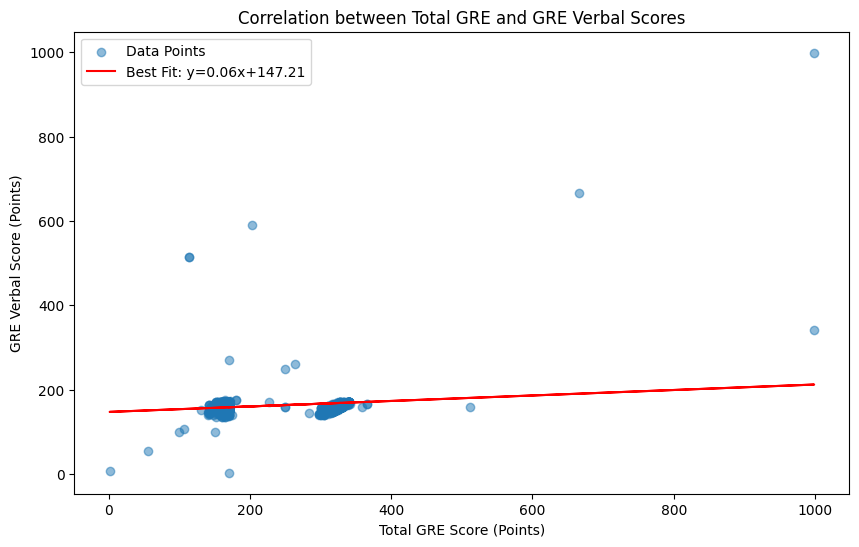

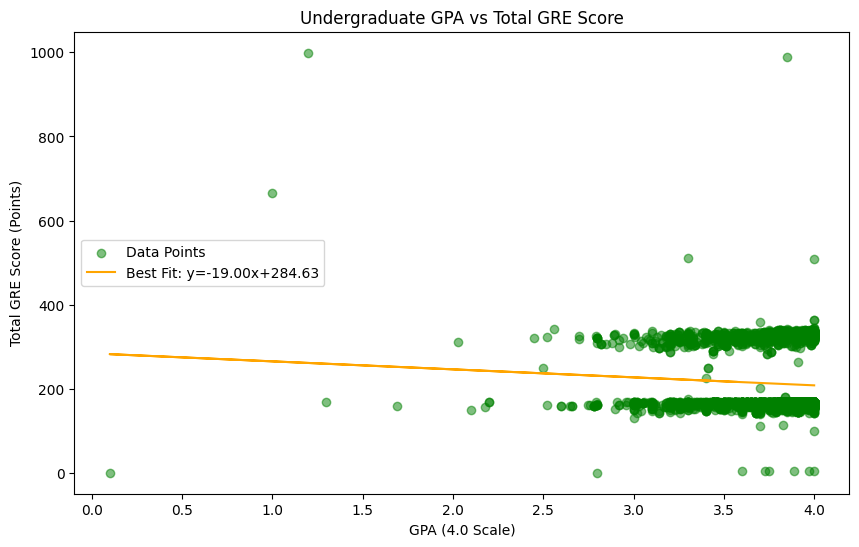

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# --- A. GRE vs GRE V ---
# Filter for non-zero and non-NaN
df_gre = df[(df['GRE'] > 0) & (df['GRE V'] > 0)].dropna(subset=['GRE', 'GRE V'])
x, y = df_gre['GRE'], df_gre['GRE V']

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, label='Data Points')
# Compute best-fit line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', label=f'Best Fit: y={m:.2f}x+{b:.2f}')

plt.title('Correlation between Total GRE and GRE Verbal Scores')
plt.xlabel('Total GRE Score (Points)')
plt.ylabel('GRE Verbal Score (Points)')
plt.legend()
plt.savefig('GRE-vs-GRE-V.png')
plt.show()

# --- B. GPA vs GRE ---
# Filter for non-zero GPA (<=4.0) and non-zero GRE
df_gpa_gre = df[(df['GPA'] > 0) & (df['GPA'] <= 4.0) & (df['GRE'] > 0)].dropna(subset=['GPA', 'GRE'])
x2, y2 = df_gpa_gre['GPA'], df_gpa_gre['GRE']

plt.figure(figsize=(10, 6))
plt.scatter(x2, y2, alpha=0.5, color='green', label='Data Points')
# Compute best-fit line
m2, b2 = np.polyfit(x2, y2, 1)
plt.plot(x2, m2*x2 + b2, color='orange', label=f'Best Fit: y={m2:.2f}x+{b2:.2f}')

plt.title('Undergraduate GPA vs Total GRE Score')
plt.xlabel('GPA (4.0 Scale)')
plt.ylabel('Total GRE Score (Points)')
plt.legend()
plt.savefig('GPA-vs-GRE.png')
plt.show()

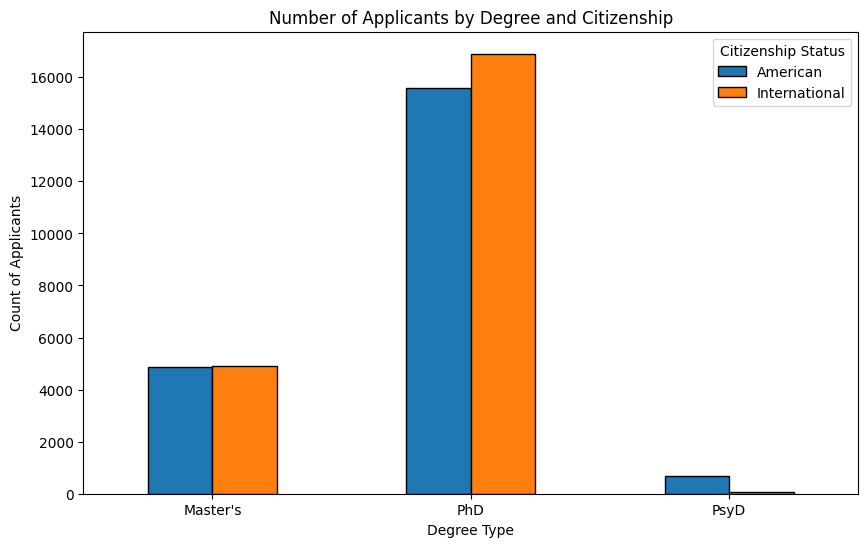

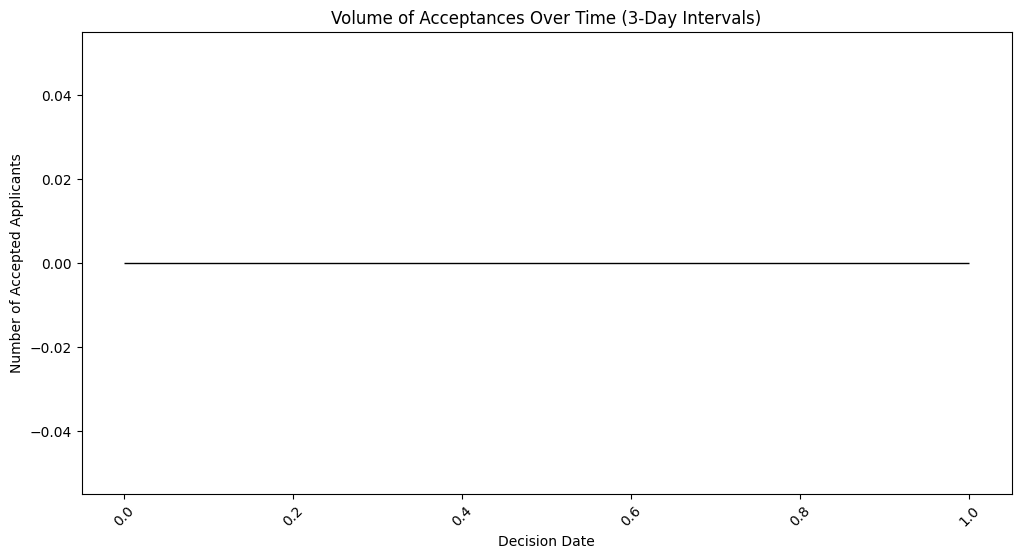

In [21]:
# --- C. Degree vs US/International (Bar Chart) ---
# Create a pivot table for the bar chart
degree_counts = df.groupby(['Degree', 'US/International']).size().unstack()
degree_counts.plot(kind='bar', figsize=(10, 6), edgecolor='black')

plt.title('Number of Applicants by Degree and Citizenship')
plt.xlabel('Degree Type')
plt.ylabel('Count of Applicants')
plt.xticks(rotation=0)
plt.legend(title='Citizenship Status')
plt.savefig('Degree-vs-International.png')
plt.show()

# --- D. Acceptances over Time (Histogram) ---
# Filter for Accepted only and valid dates
accepted_dates = df[df['outcome'] == 'Accepted']['decision_date'].dropna()

plt.figure(figsize=(12, 6))
# Calculate bins: total day range / 3
date_range = (accepted_dates.max() - accepted_dates.min()).days
num_bins = max(1, date_range // 3)

plt.hist(accepted_dates, bins=num_bins, color='skyblue', edgecolor='black')
plt.title('Volume of Acceptances Over Time (3-Day Intervals)')
plt.xlabel('Decision Date')
plt.ylabel('Number of Accepted Applicants')
plt.xticks(rotation=45)
plt.savefig('Acceptances-over-Time.png')
plt.show()

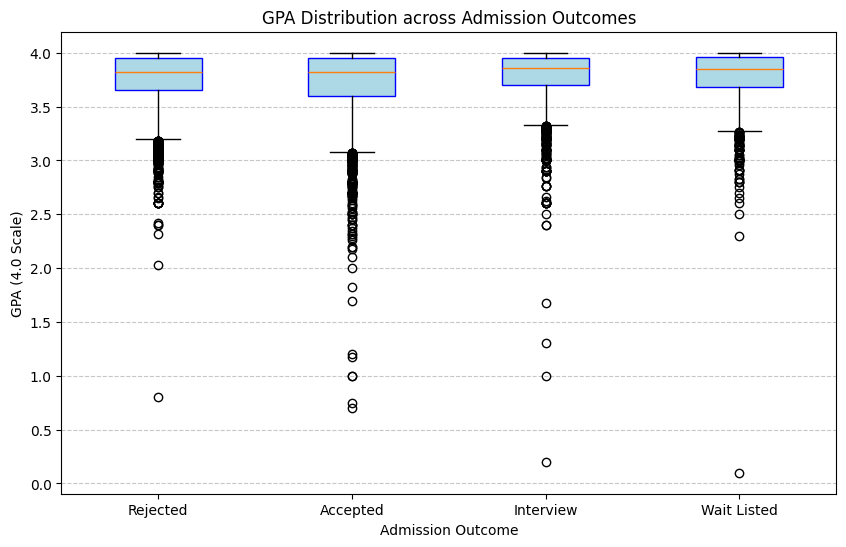

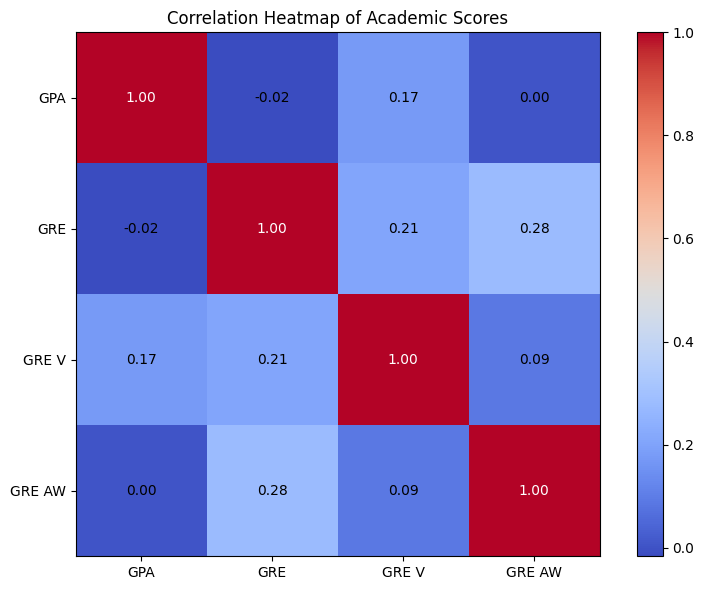

Final visualizations 'GPA-by-Outcome.png' and 'Numeric-Correlation-Heatmap.png' saved.


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- E. GPA Distribution by Outcome (Boxplot) ---
# Filter for valid GPAs and non-null outcomes
df_box = df[df['GPA'] <= 4.0].dropna(subset=['GPA', 'outcome'])

# Ensure we have data to plot
if not df_box.empty:
    # Identify unique outcomes present in the data
    outcomes = df_box['outcome'].unique()
    # Create a list of GPA arrays, one for each outcome
    groups = [df_box[df_box['outcome'] == o]['GPA'] for o in outcomes]

    plt.figure(figsize=(10, 6))
    plt.boxplot(groups, labels=outcomes, patch_artist=True, 
                boxprops=dict(facecolor='lightblue', color='blue'))
    
    plt.title('GPA Distribution across Admission Outcomes')
    plt.xlabel('Admission Outcome')
    plt.ylabel('GPA (4.0 Scale)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig('GPA-by-Outcome.png')
    plt.show()

# --- F. Numeric Correlation Heatmap (Pure Matplotlib) ---
numeric_cols = ['GPA', 'GRE', 'GRE V', 'GRE AW']
# Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
# 'imshow' creates the heatmap grid
im = plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')

# Add the color bar to show the scale (-1 to 1)
plt.colorbar(im)

# Add labels to the axes
plt.xticks(range(len(numeric_cols)), numeric_cols)
plt.yticks(range(len(numeric_cols)), numeric_cols)

# Add the numeric values inside each cell (loop through the matrix)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        val = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", 
                 color="white" if abs(val) > 0.5 else "black")

plt.title('Correlation Heatmap of Academic Scores')
plt.tight_layout()
plt.savefig('Numeric-Correlation-Heatmap.png')
plt.show()

print("Final visualizations 'GPA-by-Outcome.png' and 'Numeric-Correlation-Heatmap.png' saved.")

In [23]:
import boto3
from boto3.s3.transfer import TransferConfig

# --- FIX: Using .strip() to remove the trailing spaces seen in your error ---
MY_BUCKET = 'grad-cafe-me'.strip() 
S3_OBJECT_NAME = 'cleaned_gradcafe.json'
LOCAL_FILE = 'cleaned_gradcafe.json'

def final_upload_attempt():
    print(f"Targeting Bucket: '{MY_BUCKET}' (Trailing spaces removed)")
    
    s3_client = boto3.client('s3')
    
    # Standard configuration to avoid 'AccessDenied' on multipart calls
    config = TransferConfig(
        multipart_threshold=1024 * 100, 
        use_threads=False
    )

    try:
        s3_client.upload_file(
            LOCAL_FILE, 
            MY_BUCKET, 
            S3_OBJECT_NAME, 
            Config=config
        )
        
        print("\n" + "="*42)
        print("       S3 UPLOAD CONFIRMATION")
        print("="*42)
        print(f"✅ Success! {LOCAL_FILE} is now in S3.")
        print(f"Path: s3://{MY_BUCKET}/{S3_OBJECT_NAME}")
        print("="*42)
        
    except Exception as e:
        print(f"\n❌ Error: {e}")
        print("\nIf you see 'Access Denied' now, it likely means your AWS credentials ")
        print("are Read-Only and do not allow writing to the bucket.")

# Run the final attempt
final_upload_attempt()

Targeting Bucket: 'grad-cafe-me' (Trailing spaces removed)

       S3 UPLOAD CONFIRMATION
✅ Success! cleaned_gradcafe.json is now in S3.
Path: s3://grad-cafe-me/cleaned_gradcafe.json
